# Исследование данных (EDA): поиск услуг, кандидатогенерация

Ноутбук для подробного изучения трёх наборов данных задачи:
`train.parquet` (пары «запрос → выбранное объявление»), `benchmark_queries.parquet` (запросы без разметки), `benchmark_items.parquet` (корпус объявлений).

Содержит: схемы таблиц, распределения, графики, пересечения между наборами, поведенческие сигналы и автоматические выводы (в конце).

**Как запустить:** положите три parquet-файла в папку `data/` рядом с ноутбуком и выполните все ячейки (~2–4 минуты).
Зависимости: `pandas`, `numpy`, `matplotlib`, `pyarrow`.

In [1]:
# ===== Настройки и загрузка =====
import os, re, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (9.5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = 'data'          # папка с train.parquet / benchmark_queries.parquet / benchmark_items.parquet
SEED = 42
rng = np.random.RandomState(SEED)

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
bq    = pd.read_parquet(os.path.join(DATA_DIR, 'benchmark_queries.parquet'))
bi    = pd.read_parquet(os.path.join(DATA_DIR, 'benchmark_items.parquet'))
print('train:', train.shape, '| benchmark_queries:', bq.shape, '| benchmark_items:', bi.shape)

def norm_text(s):
    """Нормализация текста: нижний регистр, ё→е, пунктуация → пробел."""
    s = str(s).lower().replace('ё', 'е')
    s = re.sub(r'[^0-9a-zа-я]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

train: (497673, 19) | benchmark_queries: (2452, 6) | benchmark_items: (189212, 14)


## 1. Общий обзор таблиц

Смотрим состав колонок, их типы и заполненность — это фундамент для любых дальнейших выводов.

In [2]:
for name, df in [('train', train), ('benchmark_queries', bq), ('benchmark_items', bi)]:
    print('=' * 72)
    print(name, df.shape)
    info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null_share': df.notna().mean().round(3),
        'пример значения': [str(df[c].dropna().iloc[0])[:60] if df[c].notna().any() else '' for c in df.columns],
    })
    display(info)

train (497673, 19)


,dtype,non_null_share,пример значения
search_query,object,1.000,скупка телевизоров
search_location_id,int64,1.000,652430
search_is_delivery_search,int32,1.000,0
search_infm_params_text,object,1.000,
search_category,int64,1.000,114
item_title_raw,object,1.000,Скупка б/у техники
item_rating_reviews_count,float64,0.961,91.0
item_rating,float64,0.943,4.989010989010989
item_price,object,1.000,1.000000000000000
item_microcat_id,int64,1.000,2303374


benchmark_queries (2452, 6)


,dtype,non_null_share,пример значения
query_id,object,1.0,70DfDUpwjxB4lzFd
search_query,object,1.0,перевозки владикавказ тбилиси
search_location_id,int64,1.0,649820
search_is_delivery_search,int32,1.0,0
search_infm_params_text,object,1.0,
search_category,int64,1.0,114


benchmark_items (189212, 14)


,dtype,non_null_share,пример значения
item_title_raw,object,1.000,Ремонт/выкуп компьют. и ноутбуков с выездом на...
item_rating_reviews_count,float64,0.939,57.0
item_rating,float64,0.907,5.0
item_price,object,1.000,500.000000000000000
item_microcat_id,int64,1.000,2097573
item_longitude,object,1.000,42.047193961004901
item_location_id,int64,1.000,631060
item_latitude,object,1.000,44.228180450924000
item_is_phone_hidden,bool,1.000,False
item_is_message_forbidden,bool,1.000,False


In [3]:
# Примеры строк
display(train.head(3))
display(bq.head(5))
display(bi.head(3))

,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114


,query_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category
0,70DfDUpwjxB4lzFd,перевозки владикавказ тбилиси,649820,0,,114
1,JTrdTaZJvSiLPkXj,обзвон по базе,107620,0,Вид услуги Деловые услуги,114
2,LZCZNoVG4AFUkVRJ,липоредукция подбородка,637640,0,"Вид услуги Красота, здоровье",114
3,660ac9QVtXkRxZC3,подъемник 4 х стоечный,662810,0,,114
4,YgHcM9MVbxKnxD1e,монтаж видеодомофонов,642790,0,,114


,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,Ремонт/выкуп компьют. и ноутбуков с выездом на...,57.0,5.0,500.000000000000000,2097573,42.047193961004901,631060,44.228180450924000,False,False,Вид услуги Компьютерная помощь Место оказания ...,111eb8b979577d79,"Выезд на дом в любое время, вплоть до 23:00\n\...",114
1,Обучение ребенка чтению,7.0,5.0,900.000000000000000,86453,49.627391820000000,631870,58.627609249999999,False,False,"Вид услуги Обучение, курсы Место оказания услу...",75fc8e10f5a66fc4,"Дорогие родители и маленькие книголюбы! \n\nЯ,...",114
2,Афрокудри 5+,14.0,5.0,1000.000000000000000,86467,40.936892000000000,628500,56.990307000000001,True,False,"Вид услуги Красота, здоровье Место оказания ус...",3f6ae81704565b9c,ВНИМАНИЕ Укладка !!!! 🥳\n\nАФРОкудри отличный ...,114


## 2. Запросы: длины и частоты

Ключевой вопрос: насколько запросы короткие и «повторяемые». От этого зависит, насколько полезна
поведенческая память (клики других пользователей по этому же тексту).

Длина запроса (символы): train медиана 17, среднее 17.5, p95 31
Длина запроса (символы): бенчмарк медиана 22
Слов в запросе: медиана 2, среднее 2.34, p95 4


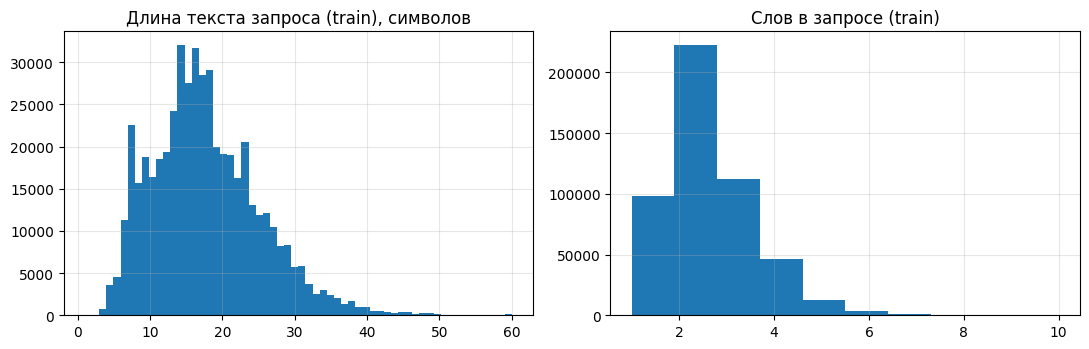

In [4]:
train_q = train['search_query'].astype(str)
bq_q    = bq['search_query'].astype(str)
tl = train_q.str.len()
bl = bq_q.str.len()
tok = train_q.map(lambda s: len(s.split()))

print('Длина запроса (символы): train медиана %.0f, среднее %.1f, p95 %.0f' % (tl.median(), tl.mean(), tl.quantile(.95)))
print('Длина запроса (символы): бенчмарк медиана %.0f' % bl.median())
print('Слов в запросе: медиана %.0f, среднее %.2f, p95 %.0f' % (tok.median(), tok.mean(), tok.quantile(.95)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(tl.clip(0, 60), bins=60); axes[0].set_title('Длина текста запроса (train), символов')
axes[1].hist(tok.clip(0, 10), bins=10); axes[1].set_title('Слов в запросе (train)')
plt.tight_layout(); plt.show()

Уникальных текстов запросов: train 74529, бенчмарк 2452
Доля строк train, приходящихся на топ-100 запросов: 25.1%


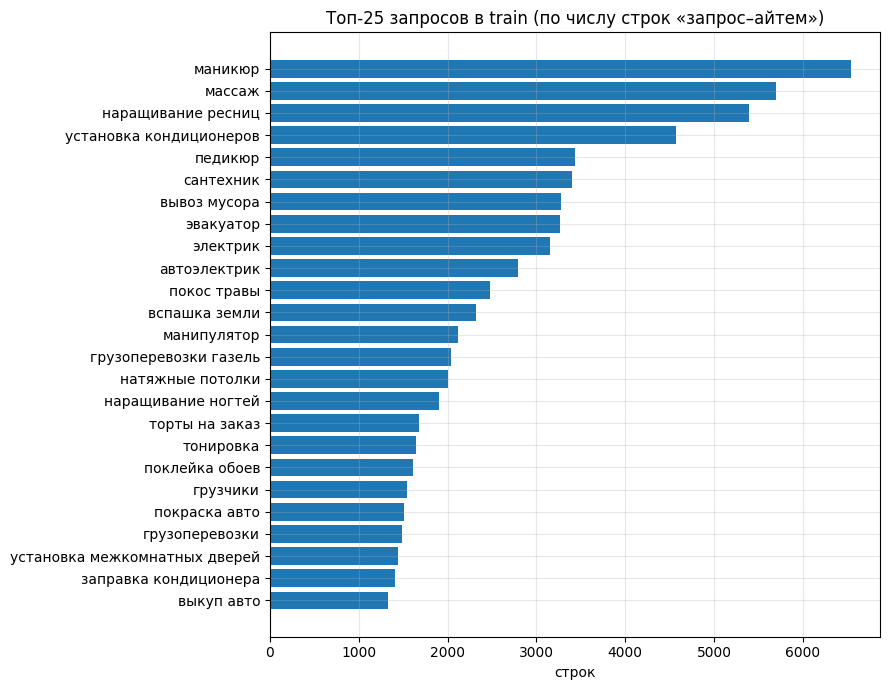

,примеры запросов бенчмарка
0,перевозки владикавказ тбилиси
1,обзвон по базе
2,липоредукция подбородка
3,подъемник 4 х стоечный
4,монтаж видеодомофонов
5,боевое самбо
6,услуги бухгалтера для ип
7,бригада по установке забора из профнастила
8,индивидуальные занятия с тренером
9,нитрид титана


In [5]:
vc = train_q.value_counts()
print('Уникальных текстов запросов: train %d, бенчмарк %d' % (train_q.nunique(), bq_q.nunique()))
print('Доля строк train, приходящихся на топ-100 запросов: %.1f%%' % (100 * vc.head(100).sum() / len(train_q)))

top = vc.head(25)[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top.index, top.values)
plt.title('Топ-25 запросов в train (по числу строк «запрос–айтем»)')
plt.xlabel('строк')
plt.tight_layout(); plt.show()

display(bq['search_query'].head(15).to_frame('примеры запросов бенчмарка'))

## 3. Корпус объявлений: тексты, категории, цена, качество

In [6]:
# Примеры карточек
examples = bi.sample(3, random_state=SEED)
for _, r in examples.iterrows():
    print('—', r['item_title_raw'])
    print('   описание :', str(r['item_description_raw'])[:130].replace(chr(10), ' '))
    print('   параметры:', str(r['item_infm_params_text'])[:170].replace(chr(10), ' '))
    print()

— Вывоз мусора
   описание : Вывезу любой мусор автомобилем Газель.
   параметры: Вид услуги Вывоз мусора и вторсырья Место оказания услуг Кемеровская область, Киселёвск Тип стоимости за услугу График работы от 25200 График работы до 82800 График работ

— Брейды, афрохвост, водопад
   описание : Привет! Я сертифицированный мастер по плетению кос и приглашаю вас на стильные и аккуратные прически с канекалоном.     ✔ низкие ц
   параметры: Вид услуги Красота, здоровье Место оказания услуг Нижний Новгород, улица Мельникова-Печерского, 1 Тип услуги Услуги парикмахера Тип стоимости за услугу Начальная цена Где

— Реконструкция волос
   описание : Восстановление волос после обесцвечивания, химии и утюжков.  Устали смотреть на тусклые, пористые, как губка, волосы?  Результат п
   параметры: Вид услуги Красота, здоровье Место оказания услуг Приморский край, Владивосток, улица Борисенко, 40с1 Тип услуги Услуги парикмахера Тип стоимости за услугу Начальная цена



Заголовок: медиана 35 симв., p95 50
описание  : медиана 1054, p95 4205


параметры : медиана 738, p95 2475


Доля айтемов с неуникальным заголовком: 36.6%


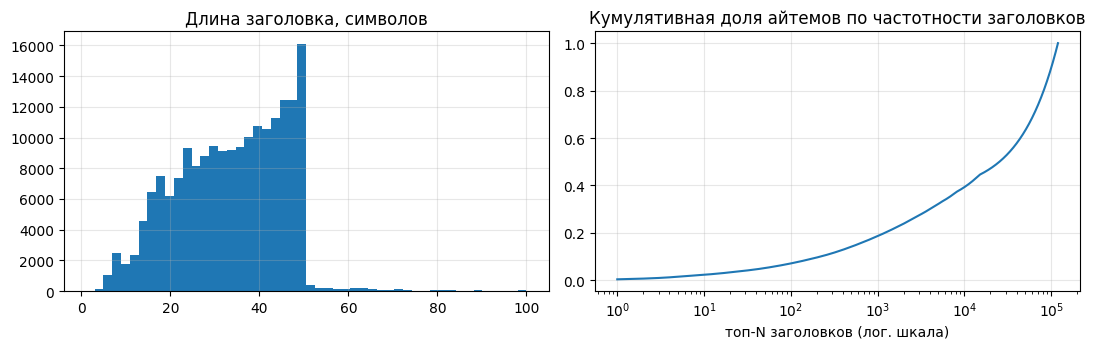

In [7]:
tlen = bi['item_title_raw'].astype(str).str.len()
print('Заголовок: медиана %.0f симв., p95 %.0f' % (tlen.median(), tlen.quantile(.95)))
for cname, col in [('описание  ', 'item_description_raw'), ('параметры ', 'item_infm_params_text')]:
    L = bi[col].astype(str).str.len()
    print('%s: медиана %.0f, p95 %.0f' % (cname, L.median(), L.quantile(.95)))
print('Доля айтемов с неуникальным заголовком: %.1f%%' % (100 * bi['item_title_raw'].duplicated().mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(tlen.clip(0, 100), bins=50); axes[0].set_title('Длина заголовка, символов')
dupv = bi['item_title_raw'].value_counts()
axes[1].plot(np.arange(1, len(dupv) + 1), np.cumsum(dupv.values) / len(bi))
axes[1].set_xscale('log')
axes[1].set_title('Кумулятивная доля айтемов по частотности заголовков')
axes[1].set_xlabel('топ-N заголовков (лог. шкала)')
plt.tight_layout(); plt.show()

Категорий в корпусе: 47 | микрокатегорий: 752
Доля самой большой категории: 99.0%


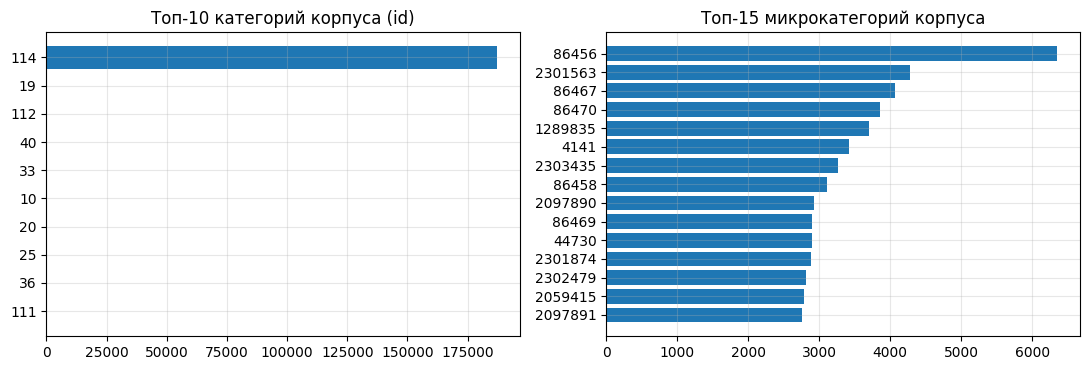

In [8]:
print('Категорий в корпусе: %d | микрокатегорий: %d' % (bi['item_category_id'].nunique(), bi['item_microcat_id'].nunique()))
print('Доля самой большой категории: %.1f%%' % (100 * bi['item_category_id'].value_counts().iloc[0] / len(bi)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
cat = bi['item_category_id'].value_counts().head(10)[::-1]
axes[0].barh(cat.index.astype(str), cat.values); axes[0].set_title('Топ-10 категорий корпуса (id)')
mc = bi['item_microcat_id'].value_counts().head(15)[::-1]
axes[1].barh(mc.index.astype(str), mc.values); axes[1].set_title('Топ-15 микрокатегорий корпуса')
plt.tight_layout(); plt.show()

Цена: медиана 1000, p25 380, p75 2500
Отзывы: медиана 18, p75 53, max 18291
Рейтинг: медиана 5.00


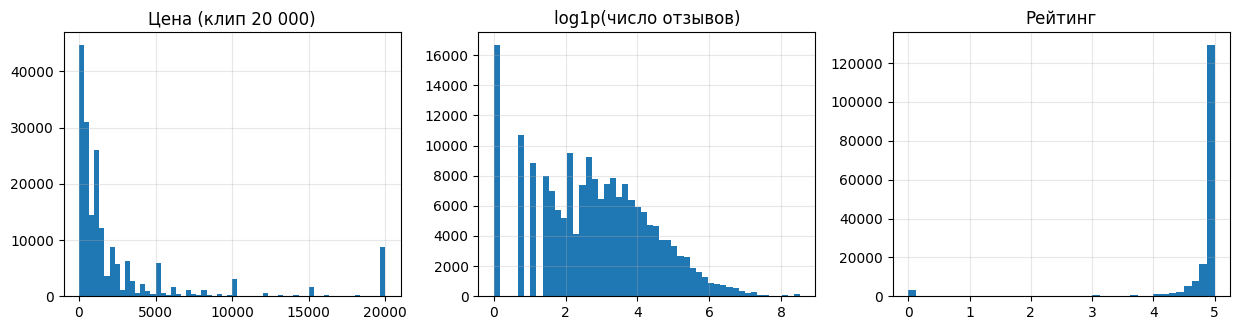

In [9]:
def dec2f(x):
    try:
        return float(x)
    except Exception:
        return np.nan

price = np.array([dec2f(x) for x in bi['item_price'].values])
rev = pd.to_numeric(bi['item_rating_reviews_count'], errors='coerce')
rat = pd.to_numeric(bi['item_rating'], errors='coerce')
print('Цена: медиана %.0f, p25 %.0f, p75 %.0f' % (np.nanmedian(price), np.nanpercentile(price, 25), np.nanpercentile(price, 75)))
print('Отзывы: медиана %.0f, p75 %.0f, max %.0f' % (rev.median(), rev.quantile(.75), rev.max()))
print('Рейтинг: медиана %.2f' % rat.median())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
p = price[~np.isnan(price)]
axes[0].hist(np.clip(p, 0, 20000), bins=60); axes[0].set_title('Цена (клип 20 000)')
axes[1].hist(np.log1p(rev.fillna(0).clip(0, 5000)), bins=50); axes[1].set_title('log1p(число отзывов)')
axes[2].hist(rat.dropna(), bins=40); axes[2].set_title('Рейтинг')
plt.tight_layout(); plt.show()

## 4. Пересечения: train ↔ корпус ↔ бенчмарк

Насколько данные «связаны»: сколько айтемов корпуса встречается в train, сколько текстов бенчмарка —
в train, и у какой доли запросов есть поведенческие кандидаты (клики по айтемам текущего корпуса).

нормализация и пересечение посчитаны за 2 сек
Айтемов корпуса, встречающихся в train: 18142 из 189212 (9.6%)
Тексты бенчмарка, встречающиеся в train: 919 из 2452 (37.5%)
Из них с кликами по айтемам корпуса: 366 (14.9% от всего бенчмарка)


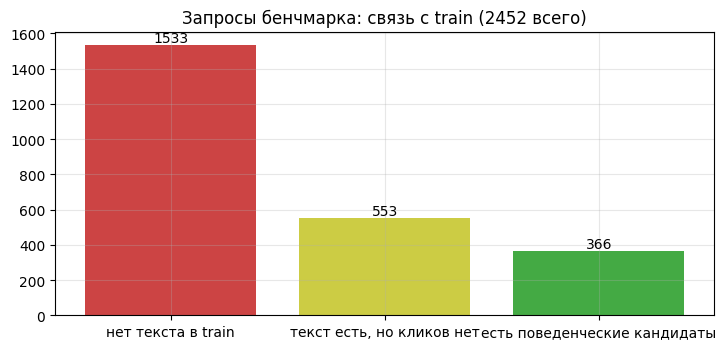

In [10]:
t0 = time.time()
train_qn = train_q.map(norm_text)
bq_qn    = bq_q.map(norm_text)
id2idx   = {v: i for i, v in enumerate(bi['item_id'].astype(str))}
tr_idx   = train['item_id'].map(id2idx)
corpus_ids = set(id2idx)

trc = pd.DataFrame({'qn': train_qn.values, 'idx': tr_idx.values}).dropna(subset=['idx'])
print('нормализация и пересечение посчитаны за %.0f сек' % (time.time() - t0))

matched = bq_qn.isin(set(train_qn))
n_matched = int(matched.sum())
covered_qs = set(trc['qn']) & set(bq_qn)
n_covered = int(bq_qn.isin(covered_qs).sum())

print('Айтемов корпуса, встречающихся в train: %d из %d (%.1f%%)' % (len(set(trc['idx'])), len(corpus_ids), 100 * len(set(trc['idx'])) / len(corpus_ids)))
print('Тексты бенчмарка, встречающиеся в train: %d из %d (%.1f%%)' % (n_matched, len(bq), 100 * n_matched / len(bq)))
print('Из них с кликами по айтемам корпуса: %d (%.1f%% от всего бенчмарка)' % (n_covered, 100 * n_covered / len(bq)))

vals = [len(bq) - n_matched, n_matched - n_covered, n_covered]
labs = ['нет текста в train', 'текст есть, но кликов нет', 'есть поведенческие кандидаты']
plt.figure(figsize=(7.5, 3.6))
bars = plt.bar(labs, vals, color=['#c44', '#cc4', '#4a4'])
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom')
plt.title('Запросы бенчмарка: связь с train (%d всего)' % len(bq))
plt.tight_layout(); plt.show()

## 5. Поведенческие сигналы

Детали «кто что выбирает»: сколько строк на запрос, сколько уникальных айтемов, как часто одну пару
«запрос–айтем» выбирают несколько пользователей (это признак «устойчивого» выбора).

Строк на запрос: медиана 1, среднее 6.75, p90 7, max 6540
Уникальных айтемов корпуса на запрос: медиана 1, p90 3
Пар «запрос–айтем», выбранных более одного раза: 9.4%


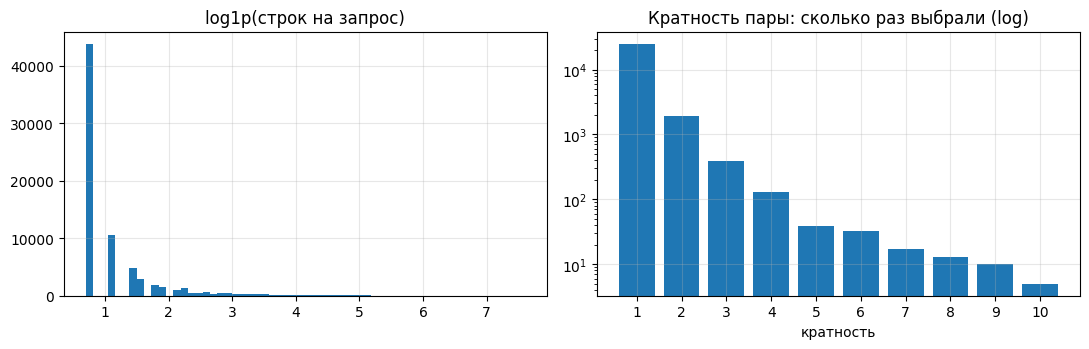

In [11]:
pairs = trc.groupby(['qn', 'idx']).size()
per_q = pairs.groupby('qn').size()
per_q_occ = train_qn.value_counts()

print('Строк на запрос: медиана %d, среднее %.2f, p90 %d, max %d' % (per_q_occ.median(), per_q_occ.mean(), per_q_occ.quantile(.9), per_q_occ.max()))
print('Уникальных айтемов корпуса на запрос: медиана %d, p90 %d' % (per_q.median(), per_q.quantile(.9)))
print('Пар «запрос–айтем», выбранных более одного раза: %.1f%%' % (100 * (pairs > 1).mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(np.log1p(per_q_occ.clip(0, 2000)), bins=60); axes[0].set_title('log1p(строк на запрос)')
m = pairs.value_counts().sort_index()
axes[1].bar(m.index[:10].astype(str), m.values[:10]); axes[1].set_yscale('log')
axes[1].set_title('Кратность пары: сколько раз выбрали (log)'); axes[1].set_xlabel('кратность')
plt.tight_layout(); plt.show()

In [12]:
# Пример: что выбирают по самым популярным запросам (наглядно про «поведение»)
titles = bi['item_title_raw'].astype(str).values
for q in per_q_occ.head(3).index:
    sub = trc[trc['qn'] == q]
    if len(sub) == 0:
        continue
    counts = sub['idx'].value_counts().head(5)
    print('Запрос: %r (всего строк %d, уникальных айтемов %d)' % (q, per_q_occ[q], len(sub)))
    for ix, c in counts.items():
        print('   %3d клик(ов) | %s' % (c, titles[int(ix)][:75]))
    print()

Запрос: 'маникюр' (всего строк 6540, уникальных айтемов 305)
    18 клик(ов) | Маникюр все включено/ педикюр. Уралмаш
     4 клик(ов) | Маникюр педикюр наращивание. М. Щелковское
     4 клик(ов) | Маниюр/педикюр/покрытие/наращивание ногтей
     3 клик(ов) | Маникюр и педикюр, оформление бровей
     3 клик(ов) | Маникюр с покрытием гель лак

Запрос: 'массаж' (всего строк 5704, уникальных айтемов 333)
    13 клик(ов) | Массаж услуга в нальчике
    13 клик(ов) | Массаж
     9 клик(ов) | Светлана Нальчик Массаж
     8 клик(ов) | Массаж
     7 клик(ов) | Массаж

Запрос: 'наращивание ресниц' (всего строк 5398, уникальных айтемов 329)
     7 клик(ов) | LED наращивание ресниц/Ламинирование ресниц
     7 клик(ов) | Наращивание ресниц /LED наращивание, ламинирование
     5 клик(ов) | Наращивание ресниц любой сложности
     4 клик(ов) | Трендовое наращивание ресниц
     4 клик(ов) | LED-наращивание ресниц метро Звёздная



Запросов с >=5 кликами по корпусу: 1034
Доля кликов в самой популярной микрокатегории запроса: медиана 0.94, p25 0.75, p75 1.00


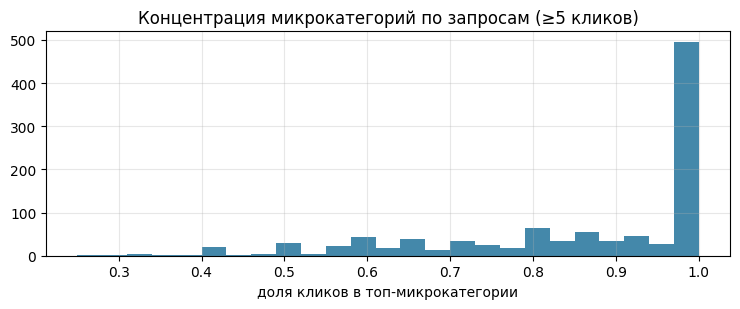

In [13]:
# Насколько однотипны выборы по запросу: концентрация микрокатегорий
trc2 = pd.DataFrame({'qn': train_qn.values, 'idx': tr_idx.values, 'mc': train['item_microcat_id'].values}).dropna(subset=['idx'])
g = trc2.groupby('qn')['mc']
top_share = g.agg(lambda s: s.value_counts().iloc[0] / len(s))
cnt = g.size()
ts = top_share[cnt >= 5]
print('Запросов с >=5 кликами по корпусу: %d' % len(ts))
print('Доля кликов в самой популярной микрокатегории запроса: медиана %.2f, p25 %.2f, p75 %.2f' % (ts.median(), ts.quantile(.25), ts.quantile(.75)))

plt.figure(figsize=(7.5, 3.2))
plt.hist(ts, bins=25, color='#48a')
plt.title('Концентрация микрокатегорий по запросам (≥5 кликов)')
plt.xlabel('доля кликов в топ-микрокатегории')
plt.tight_layout(); plt.show()

## 6. Локации и текстовые фильтры поиска

Доля пар «запрос–айтем» из одной локации: 83.1%
Локации: в train 2782 уникальных, в корпусе 2877; у 82.6% строк бенчмарка локация есть в корпусе


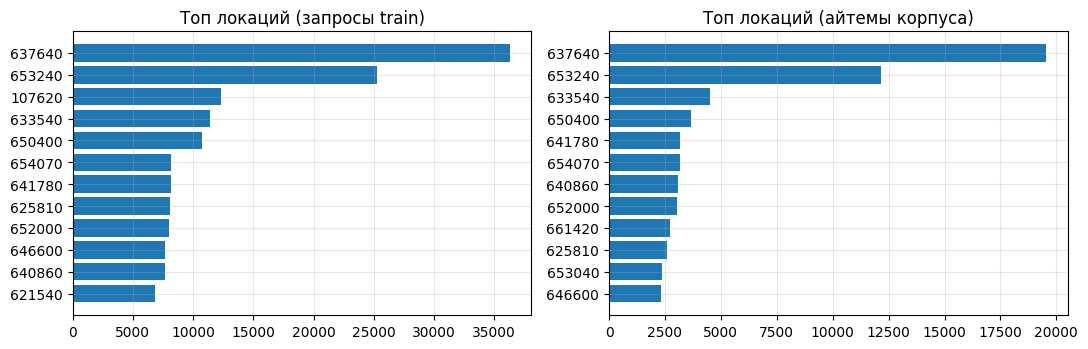

In [14]:
same_loc = (train['item_location_id'].values == train['search_location_id'].values).mean()
print('Доля пар «запрос–айтем» из одной локации: %.1f%%' % (100 * same_loc))
locs = set(bi['item_location_id'].astype(int))
print('Локации: в train %d уникальных, в корпусе %d; у %.1f%% строк бенчмарка локация есть в корпусе' % (
    train['search_location_id'].nunique(), bi['item_location_id'].nunique(),
    100 * bq['search_location_id'].isin(locs).mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
tl12 = train['search_location_id'].value_counts().head(12)[::-1]
axes[0].barh(tl12.index.astype(str), tl12.values); axes[0].set_title('Топ локаций (запросы train)')
cl12 = bi['item_location_id'].value_counts().head(12)[::-1]
axes[1].barh(cl12.index.astype(str), cl12.values); axes[1].set_title('Топ локаций (айтемы корпуса)')
plt.tight_layout(); plt.show()

In [15]:
print('Пустой search_infm_params_text: train %.1f%%, бенчмарк %.1f%%' % (
    100 * (train['search_infm_params_text'].astype(str).str.strip() == '').mean(),
    100 * (bq['search_infm_params_text'].astype(str).str.strip() == '').mean()))
print()
print('Топ-12 значений search_infm_params_text в train:')
display(train['search_infm_params_text'].value_counts().head(12).to_frame('строк').head(12))
print('Топ-8 значений search_infm_params_text в бенчмарке:')
display(bq['search_infm_params_text'].value_counts().head(8).to_frame('запросов'))

Пустой search_infm_params_text: train 33.0%, бенчмарк 63.1%

Топ-12 значений search_infm_params_text в train:


,строк
search_infm_params_text,
,163999
"Вид услуги Автосервис, аренда Тип услуги Автосервис",19654
Вид услуги Ремонт и отделка,15586
"Вид услуги Красота, здоровье",15355
"Вид услуги Праздники, мероприятия",12474
"Тип услуги автосервиса Диагностика и ремонт авто Вид услуги Автосервис, аренда Тип услуги Автосервис",11644
"Тип услуги Маникюр, педикюр Вид услуги Красота, здоровье",11589
"Вид услуги Обучение, курсы",11080
Вид услуги,10566


Топ-8 значений search_infm_params_text в бенчмарке:


,запросов
search_infm_params_text,
,1546
Вид услуги,60
"Вид услуги Оборудование, производство",53
Вид услуги Ремонт и отделка,48
"Вид услуги Праздники, мероприятия",40
"Вид услуги Обучение, курсы",39
"Вид услуги Красота, здоровье",36
Вид услуги Вывоз мусора и вторсырья,36


## 7. Выбранные объявления vs весь корпус

Сравниваем «портрет» выбранных пользователями айтемов (train) с корпусом: отзывы, рейтинг. Это то, что
помогает ранжировать похожие объявления.

Отзывы: медиана | выбранные 25 | корпус 18
Доля карточек без отзывов (среди заполненных): выбранные 2.02% | корпус 2.85%
Нет данных об отзывах: выбранные 3.86% | корпус 6.14%
Рейтинг: медиана | выбранные 5.00 | корпус 5.00


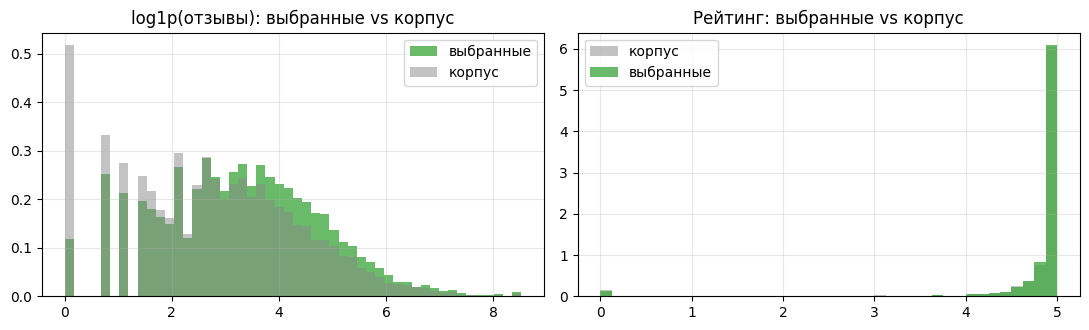

In [16]:
rev_tr_raw = pd.to_numeric(train['item_rating_reviews_count'], errors='coerce')
rev_bi = pd.to_numeric(bi['item_rating_reviews_count'], errors='coerce')
rev_tr = rev_tr_raw.dropna()
rat_tr = pd.to_numeric(train['item_rating'], errors='coerce').dropna()
rat_bi = pd.to_numeric(bi['item_rating'], errors='coerce')
zero_bi = (rev_bi == 0).sum() / max(1, rev_bi.notna().sum())

print('Отзывы: медиана | выбранные %.0f | корпус %.0f' % (rev_tr.median(), rev_bi.median()))
print('Доля карточек без отзывов (среди заполненных): выбранные %.2f%% | корпус %.2f%%' % (100 * (rev_tr == 0).mean(), 100 * zero_bi))
print('Нет данных об отзывах: выбранные %.2f%% | корпус %.2f%%' % (100 * rev_tr_raw.isna().mean(), 100 * rev_bi.isna().mean()))
print('Рейтинг: медиана | выбранные %.2f | корпус %.2f' % (rat_tr.median(), rat_bi.median()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(np.log1p(rev_tr.clip(0, 5000)), bins=50, alpha=.8, density=True, color='#4a4', label='выбранные')
axes[0].hist(np.log1p(rev_bi.fillna(0).clip(0, 5000)), bins=50, alpha=.5, density=True, color='#888', label='корпус')
axes[0].legend(); axes[0].set_title('log1p(отзывы): выбранные vs корпус')
axes[1].hist(rat_bi.dropna(), bins=40, alpha=.5, density=True, color='#888', label='корпус')
axes[1].hist(rat_tr, bins=40, alpha=.8, density=True, color='#4a4', label='выбранные')
axes[1].legend(); axes[1].set_title('Рейтинг: выбранные vs корпус')
plt.tight_layout(); plt.show()

## 8. Главные выводы

Автоматическая сводка наблюдений — то, на что стоит опираться при построении решения.

In [17]:
print('Ключевые наблюдения по данным:')
print()
print('1) Запросы короткие (медиана ~%.0f символов, ~%.0f слов) и массово повторяются: топ-100 текстов = %.1f%% строк.' % (
    tl.median(), tok.median(), 100 * vc.head(100).sum() / len(train_q)))
print('   → поведенческая память (клики по тому же тексту) — самый точный сигнал;')
print('2) В корпусе %.0f%% айтемов с неуникальными заголовками — среди похожих различают локация, качество, микрокатегория.' % (
    100 * bi['item_title_raw'].duplicated().mean()))
print('3) Выбранные объявления «устоявшиеся»: медиана отзывов %.0f против %.0f по корпусу; без отзывов %.2f%% против %.2f%% (нет данных: %.2f%% против %.2f%%).' % (
    rev_tr.median(), rev_bi.median(), 100 * (rev_tr == 0).mean(), 100 * zero_bi,
    100 * rev_tr_raw.isna().mean(), 100 * rev_bi.isna().mean()))
print('4) %.0f%% пар train — из одной локации: совпадение локации — сильный ранжирующий сигнал.' % (100 * same_loc))
print('5) Связь с бенчмарком: текст %.1f%% запросов встречается в train, у %.1f%% есть поведенческие кандидаты;' % (
    100 * n_matched / len(bq), 100 * n_covered / len(bq)))
print('   для остальных решает текстовый поиск — именно поэтому в решении работают оба канала.')
print('6) Микрокатегории концентрированы: медианная доля кликов в топ-микрокатегории запроса — %.2f:' % ts.median())
print('   микрокатегория — полезный признак «типа услуги» для запроса.')

Ключевые наблюдения по данным:

1) Запросы короткие (медиана ~17 символов, ~2 слов) и массово повторяются: топ-100 текстов = 25.1% строк.
   → поведенческая память (клики по тому же тексту) — самый точный сигнал;
2) В корпусе 37% айтемов с неуникальными заголовками — среди похожих различают локация, качество, микрокатегория.
3) Выбранные объявления «устоявшиеся»: медиана отзывов 25 против 18 по корпусу; без отзывов 2.02% против 2.85% (нет данных: 3.86% против 6.14%).
4) 83% пар train — из одной локации: совпадение локации — сильный ранжирующий сигнал.
5) Связь с бенчмарком: текст 37.5% запросов встречается в train, у 14.9% есть поведенческие кандидаты;
   для остальных решает текстовый поиск — именно поэтому в решении работают оба канала.
6) Микрокатегории концентрированы: медианная доля кликов в топ-микрокатегории запроса — 0.94:
   микрокатегория — полезный признак «типа услуги» для запроса.
